In [35]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [36]:
!pip install -q shap pyod

In [37]:

import pandas as pd
import numpy as np
from ast import literal_eval
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt
from tqdm import tqdm


In [38]:
import pandas as pd, numpy as np, ast
df=pd.read_csv("/content/gdrive/MyDrive/Pulse oxiometer/3D_Patient_Oxygen_Data.csv")
df.head()

,Patient ID,Gender,Smoking Status,BMI,Age,Oxygen Readings
0,301116B,M,Non-Smoker,21.7,20,"[98.4, 98.4, 98.4, 98.4, 98.4, 98.4, 98.4, 98...."
1,301116A,M,Non-Smoker,26.5,42,"[98.6, 98.6, 98.2, 97.5, 97.5, 97.5, 97.5, 97...."
2,051216A,M,Non-Smoker,22.0,20,"[95.5, 95.5, 95.5, 95.5, 95.5, 95.5, 95.5, 95...."
3,081216A,M,Non-Smoker,23.6,20,"[97.5, 97.5, 97.5, 97.1, 96.5, 96.5, 96.5, 96...."
4,101216A,F,Non-Smoker,24.1,45,"[98.6, 98.6, 98.6, 98.6, 98.6, 98.6, 98.6, 98...."


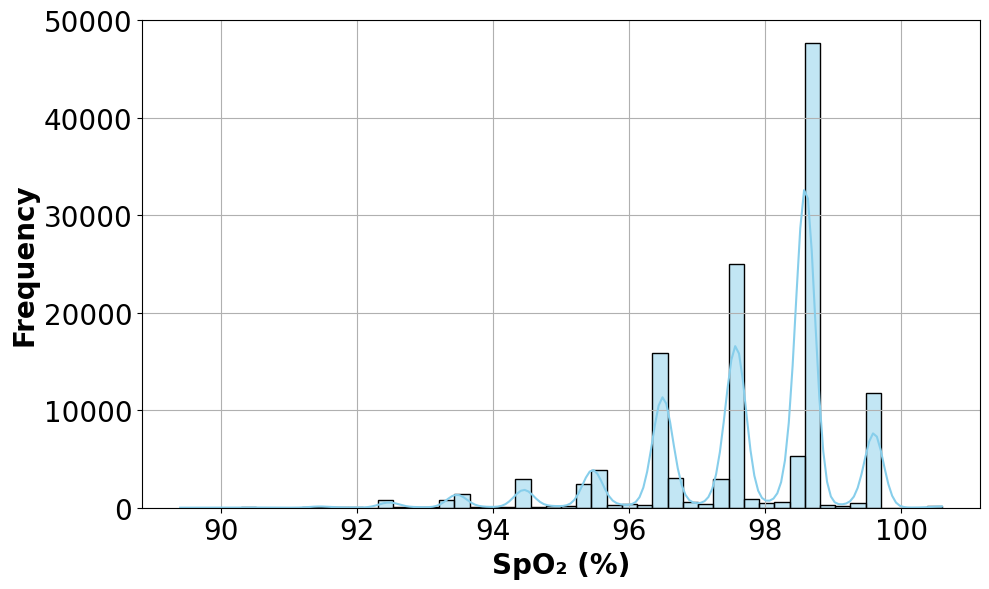

In [39]:
# 1. Data set Description
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from ast import literal_eval

# Convert string to list
def parse_readings(x):
    try:
        return literal_eval(x)
    except:
        return np.nan

df["Oxygen_Readings_List"] = df["Oxygen Readings"].apply(parse_readings)
df = df.dropna(subset=["Oxygen_Readings_List"])

# Flatten all SpO₂ readings into a single list
all_spo2_values = np.concatenate(df["Oxygen_Readings_List"].values)

# Histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(all_spo2_values, bins=50, kde=True, color="skyblue")

plt.xlabel("SpO₂ (%)",fontsize=20, fontweight='bold')
plt.ylabel("Frequency", fontsize=20, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=20)

plt.grid(True)
plt.tight_layout()
plt.show()


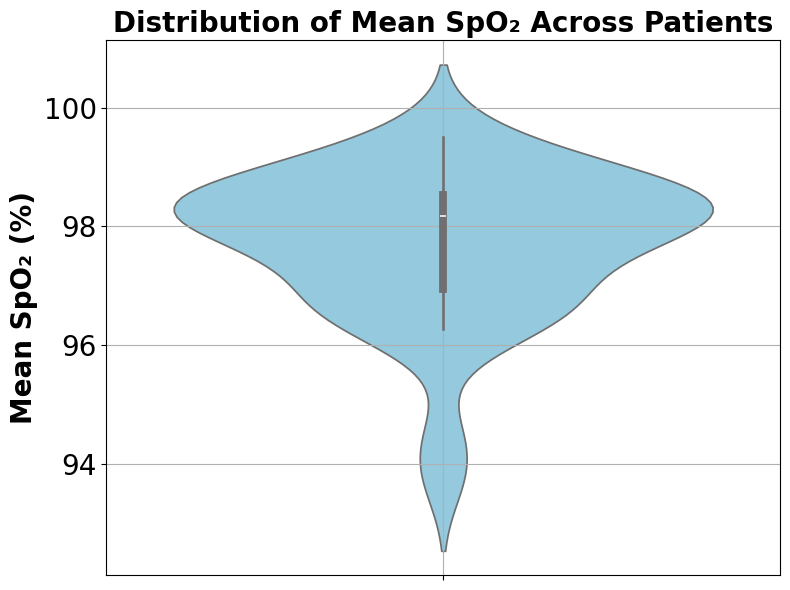

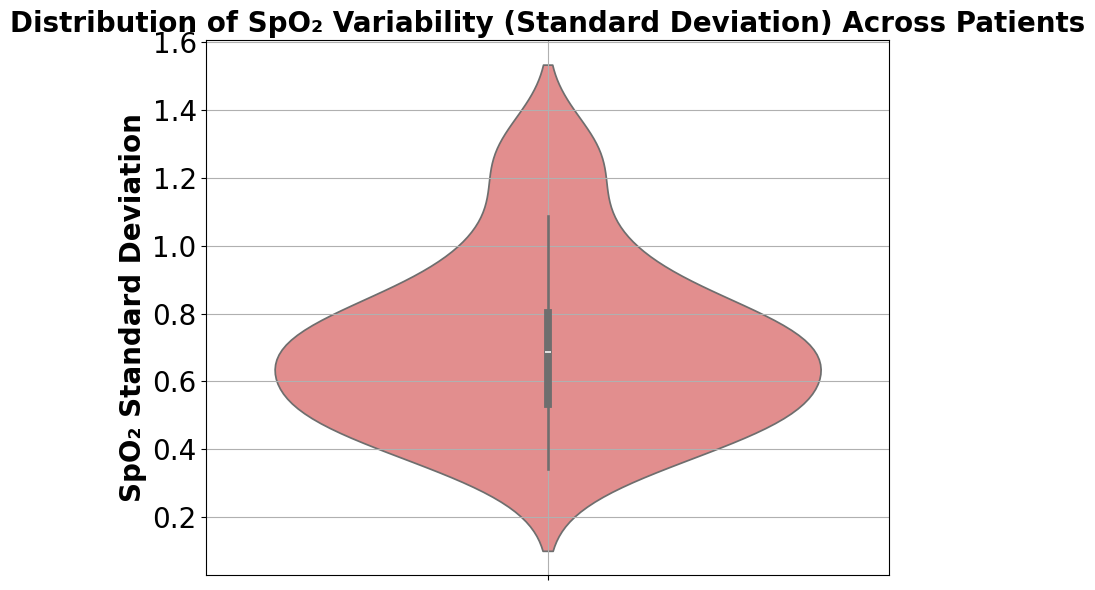

In [40]:
# 1. Data set Description

df['Oxygen_Readings_List'] = df['Oxygen Readings'].apply(lambda x: literal_eval(x) if isinstance(x, str) else np.nan)
df = df.dropna(subset=['Oxygen_Readings_List'])

# Compute per-patient mean SpO₂
df['Mean_SpO2'] = df['Oxygen_Readings_List'].apply(np.mean)
df['SpO2_STD'] = df['Oxygen_Readings_List'].apply(np.std)
#fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean SpO2
plt.figure(figsize=(8, 6))
sns.violinplot(y=df['Mean_SpO2'], color='skyblue', inner='box')
plt.title("Distribution of Mean SpO₂ Across Patients")
plt.ylabel("Mean SpO₂ (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

#  Plot 2: SpO2 Standard Deviation
plt.figure(figsize=(8, 6))
sns.violinplot(y=df['SpO2_STD'], color='lightcoral', inner='box')
plt.title("Distribution of SpO₂ Variability (Standard Deviation) Across Patients")
plt.ylabel("SpO₂ Standard Deviation")
plt.grid(True)
plt.tight_layout()
plt.show()

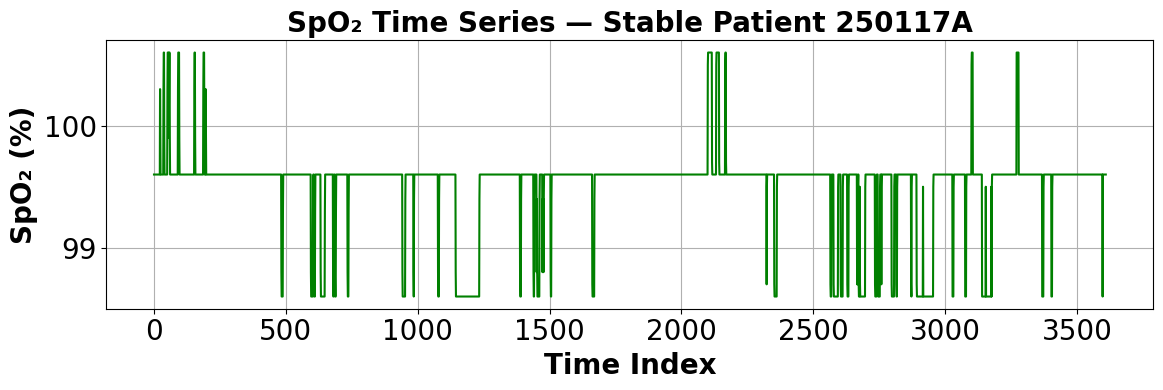

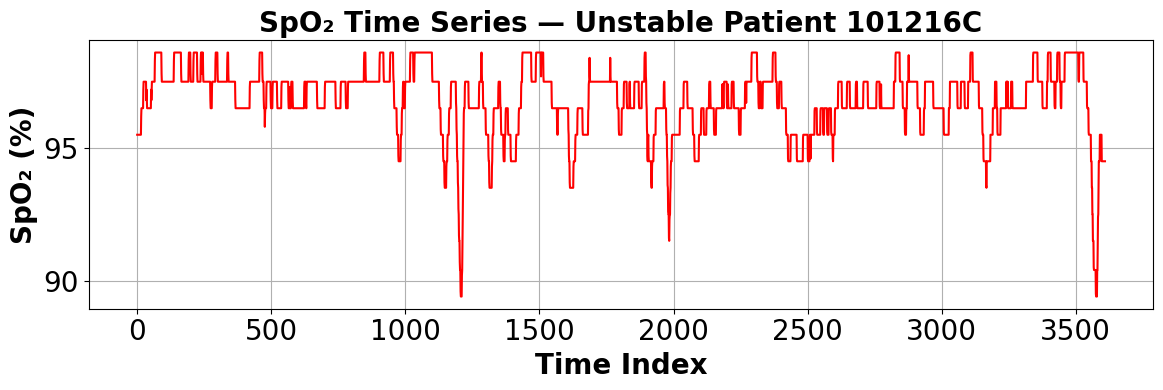

In [41]:
# Example Plot of stable and unstable patient Spo2
def plot_spo2_time_series(patient_id, color, title_label):
    patient_row = df[df['Patient ID'] == patient_id]
    if not patient_row.empty:
        spo2_values = np.array(patient_row['Oxygen_Readings_List'].values[0])
        time_index = np.arange(len(spo2_values))
        plt.figure(figsize=(12, 4))
        plt.plot(time_index, spo2_values, color=color, linewidth=1.5)
        plt.title(f"SpO₂ Time Series — {title_label} Patient {patient_id}")
        plt.xlabel("Time Index")
        plt.ylabel("SpO₂ (%)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Patient ID {patient_id} not found.")

# Plot stable patient
plot_spo2_time_series('250117A', 'green', 'Stable')

# Plot unstable patient
plot_spo2_time_series('101216C', 'red', 'Unstable')

In [42]:
# 2. Preprocess Data
def parse_readings(x):
    try:
        return np.array(literal_eval(x), dtype=float)
    except (ValueError, SyntaxError):
        return np.nan  # mark faulty rows

df['Oxygen_Readings_List'] = df['Oxygen Readings'].progress_apply(parse_readings)

# Drop rows that failed to parse
bad_rows = df['Oxygen_Readings_List'].isna().sum()
if bad_rows:
    print(f"Dropped {bad_rows} rows due to parsing errors.")
    df = df.dropna(subset=['Oxygen_Readings_List']).reset_index(drop=True)

#%%

AttributeError: 'Series' object has no attribute 'progress_apply'

In [43]:
#  Expand to long format (one row per reading)
# We'll assume readings are sampled at a uniform rate (index 0,1,2,...)
# Add a 'Time_Index' column representing the sample position.
long_rows = []
for idx, row in df.iterrows():
    readings = row['Oxygen_Readings_List']
    for t, val in enumerate(readings):
        long_rows.append({
            'Patient_ID': row['Patient ID'],
            'Gender': row['Gender'],
            'Smoking_Status': row['Smoking Status'],
            'BMI': row['BMI'],
            'Age': row['Age'],
            'Time_Index': t,
            'SpO2': val
        })
long_df = pd.DataFrame(long_rows)
print(f"Long format shape: {long_df.shape}")
print(long_df)

Long format shape: (129886, 7)
       Patient_ID Gender Smoking_Status   BMI  Age  Time_Index  SpO2
0         301116B      M     Non-Smoker  21.7   20           0  98.4
1         301116B      M     Non-Smoker  21.7   20           1  98.4
2         301116B      M     Non-Smoker  21.7   20           2  98.4
3         301116B      M     Non-Smoker  21.7   20           3  98.4
4         301116B      M     Non-Smoker  21.7   20           4  98.4
...           ...    ...            ...   ...  ...         ...   ...
129881    150317B      M     Non-Smoker  19.9   48        3594  98.6
129882    150317B      M     Non-Smoker  19.9   48        3595  98.6
129883    150317B      M     Non-Smoker  19.9   48        3596  98.6
129884    150317B      M     Non-Smoker  19.9   48        3597  98.6
129885    150317B      M     Non-Smoker  19.9   48        3598  98.6

[129886 rows x 7 columns]


In [44]:
# 3. Rolling window features
# ----------------------
# We create rolling‑window statistics per patient: mean, std, min, max, diff.
WINDOW = 10  # Number of samples. You may change and look for diffrent results

feature_df = []
for pid, grp in long_df.groupby('Patient_ID'):
    grp = grp.sort_values('Time_Index').reset_index(drop=True)
    # Rolling statistics
    grp['roll_mean'] = grp['SpO2'].rolling(WINDOW, min_periods=1).mean()
    grp['roll_std']  = grp['SpO2'].rolling(WINDOW, min_periods=1).std().fillna(0)
    grp['roll_min']  = grp['SpO2'].rolling(WINDOW, min_periods=1).min()
    grp['roll_max']  = grp['SpO2'].rolling(WINDOW, min_periods=1).max()
    # First derivative (rate of change)
    grp['diff'] = grp['SpO2'].diff().fillna(0)
    feature_df.append(grp)

enriched_df = pd.concat(feature_df).reset_index(drop=True)

# Select numeric feature columns
num_cols = ['SpO2', 'roll_mean', 'roll_std', 'roll_min', 'roll_max', 'diff']
X = enriched_df[num_cols].values
print(X)

#%%

[[98.6 98.6  0.  98.6 98.6  0. ]
 [98.6 98.6  0.  98.6 98.6  0. ]
 [98.6 98.6  0.  98.6 98.6  0. ]
 ...
 [98.4 98.4  0.  98.4 98.4  0. ]
 [98.4 98.4  0.  98.4 98.4  0. ]
 [98.4 98.4  0.  98.4 98.4  0. ]]


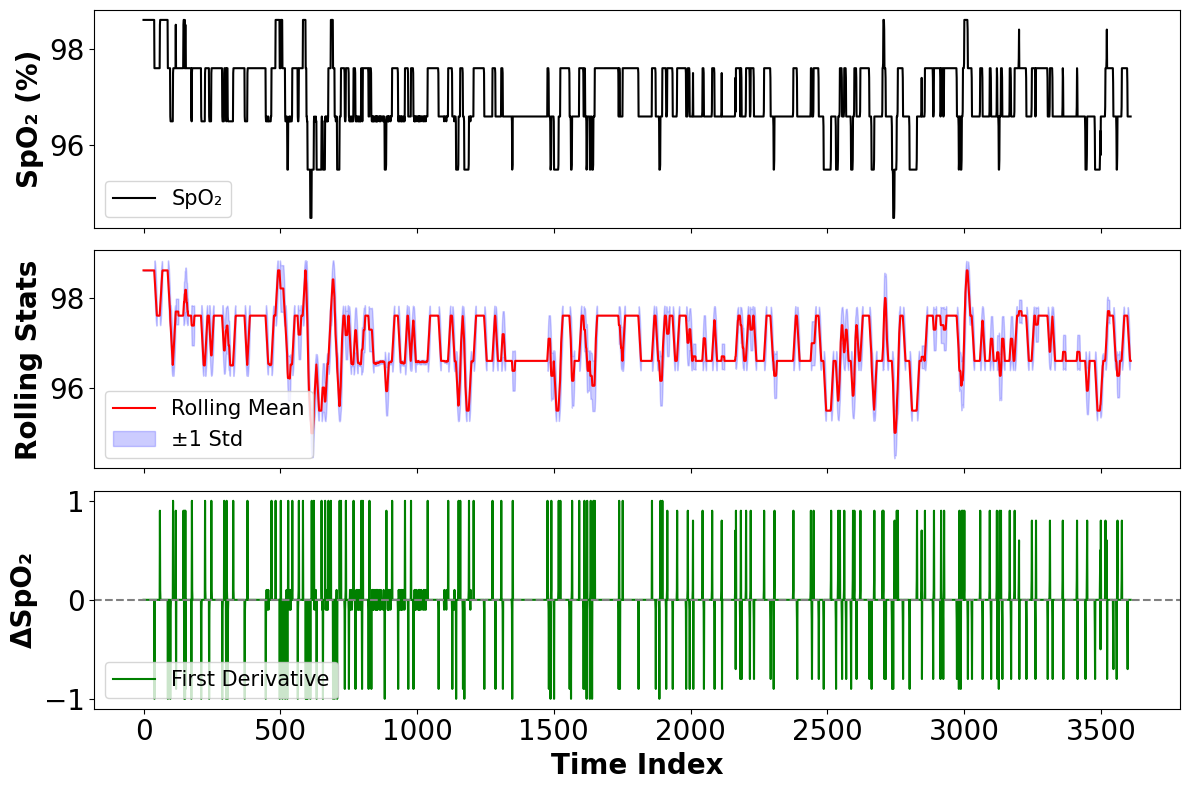

In [45]:
#pid_example = "010217C"
#pid_example = "101216C"
pid_example="160217C"
df_plot = enriched_df[enriched_df['Patient_ID'] == pid_example].copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
plt.xlabel("SpO₂ (%)",fontsize=20, fontweight='bold')
plt.ylabel("Frequency", fontsize=20, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=20)


axes[0].plot(df_plot['Time_Index'], df_plot['SpO2'], label="SpO₂", color="black")
axes[0].set_ylabel("SpO₂ (%)", fontweight="bold",fontsize=20)
axes[0].legend(loc="lower left",fontsize=15)
#axes[0].set_title(f"Patient {pid_example}: Raw and Derived Features")

# Panel 2: Rolling mean & std
axes[1].plot(df_plot['Time_Index'], df_plot['roll_mean'], label="Rolling Mean", color="red")
axes[1].fill_between(df_plot['Time_Index'],
                     df_plot['roll_mean'] - df_plot['roll_std'],
                     df_plot['roll_mean'] + df_plot['roll_std'],
                     color="blue", alpha=0.2, label="±1 Std")
axes[1].set_ylabel("Rolling Stats", fontweight="bold",fontsize=20)
axes[1].legend(loc="lower left", fontsize=15)

# Panel 3: First derivative
axes[2].plot(df_plot['Time_Index'], df_plot['diff'], label="First Derivative", color="green")
axes[2].axhline(0, linestyle="--", color="gray")
axes[2].set_xlabel("Time Index",fontweight="bold",fontsize=20)
axes[2].set_ylabel("ΔSpO₂", fontweight="bold",fontsize=20)
axes[2].legend(loc="lower left", fontsize=15)
plt.tight_layout()
plt.show()

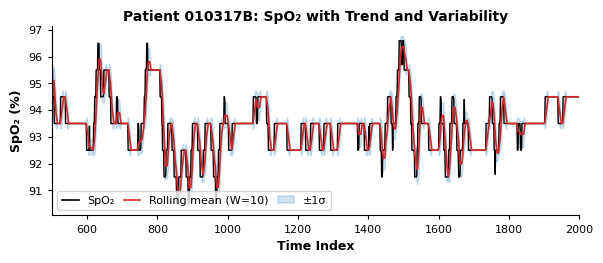

In [46]:
import matplotlib.pyplot as plt

pid = "010317B"
dfp = enriched_df[enriched_df["Patient_ID"] == pid].copy()

fig, ax = plt.subplots(figsize=(6.0, 2.6))  # compact for IEEE columns

t = dfp["Time_Index"]
spo2 = dfp["SpO2"]
m = dfp["roll_mean"]
s = dfp["roll_std"]

# Raw SpO2
ax.plot(t, spo2, lw=1.0, color="black", label="SpO₂")

# Rolling mean
ax.plot(t, m, lw=1.2, color="tab:red", label=f"Rolling mean (W={WINDOW})")

# ±1 std shaded band
ax.fill_between(t, m - s, m + s, alpha=0.2, color="tab:blue", label="±1σ")

# Styling for tight IEEE figure
ax.set_ylabel("SpO₂ (%)", fontsize=9)
ax.set_xlabel("Time Index", fontsize=9)
ax.set_title(f"Patient {pid}: SpO₂ with Trend and Variability", fontsize=10, pad=4)

# Compact legend inside plot
leg = ax.legend(loc="lower left", fontsize=8, frameon=True, framealpha=0.8, ncols=3, handlelength=1.5, columnspacing=0.8)
for lh in leg.legend_handles:
    lh.set_linewidth(1.2)

# Minimal ticks & margins
ax.tick_params(axis="both", labelsize=8, length=3)
ax.margins(x=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.set_xlim(500, 2000)
plt.tight_layout(pad=0.6)
plt.show()


Threshold at 1%: score < -0.1733 → 1299 anomalies
Threshold at 3%: score < -0.1250 → 3897 anomalies
Threshold at 5%: score < -0.0879 → 6351 anomalies


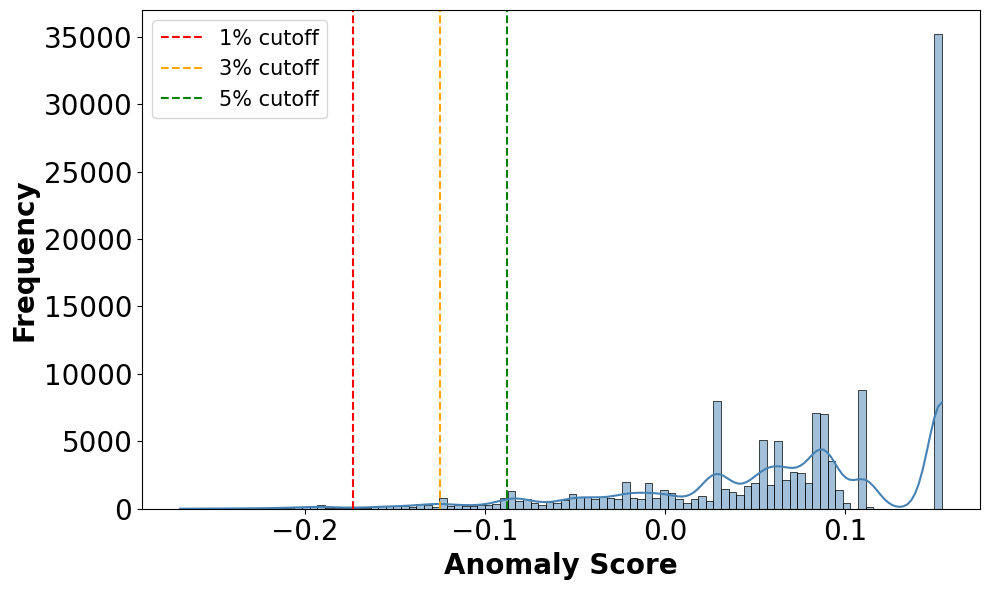

In [47]:
#4. Isolation Forest Model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
iso.fit(X_scaled)

# Prediction scores: lower scores → more anomalous
scores = iso.decision_function(X_scaled)


enriched_df['anomaly_score'] = scores

for p in [1, 3, 5]: #thresholds 1% 3% 5%
    threshold = np.percentile(scores, p)
    enriched_df[f'is_anomaly_{p}pct'] = enriched_df['anomaly_score'] < threshold
    print(f"Threshold at {p}%: score < {threshold:.4f} → {enriched_df[f'is_anomaly_{p}pct'].sum()} anomalies")

# Visualize the anomaly score distribution
plt.figure(figsize=(10, 6))
plt.rcParams.update({
    'axes.labelsize': 20,         # x and y label size
    'axes.labelweight': 'bold',   # make labels bold
    'xtick.labelsize': 20,        # x tick size
    'ytick.labelsize': 20,        # y tick size
    'axes.titlesize': 20,         # subplot/figure title size
    'axes.titleweight': 'bold',   # subplot/figure title bold
    'legend.fontsize': 15         # legend text size
})
sns.histplot(scores, bins=100, kde=True, color='steelblue')
for p, c in zip([1, 3, 5], ['red', 'orange', 'green']):
    threshold = np.percentile(scores, p)
    plt.axvline(threshold, linestyle='--', color=c, label=f'{p}% cutoff')


plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

Top 1%: score ≥ 0.1733 → 1299 anomalies
Top 3%: score ≥ 0.1250 → 3897 anomalies
Top 5%: score ≥ 0.0879 → 6690 anomalies


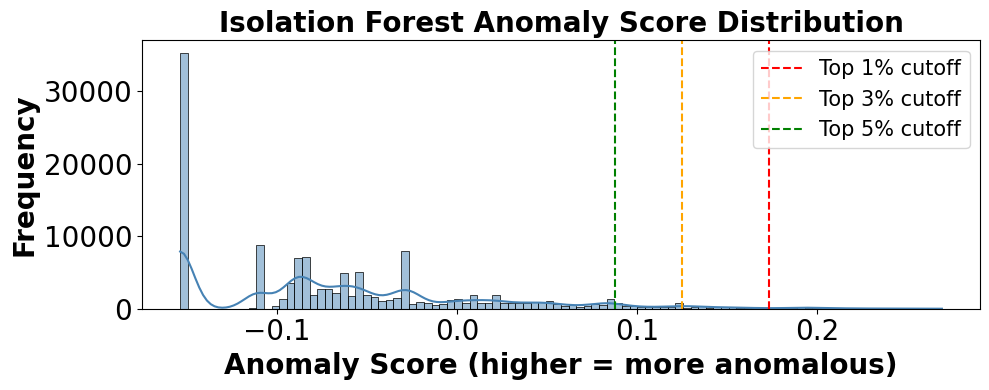

In [48]:
# 4. Isolation Forest Model (with anomaly_score = higher means more anomalous)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Isolation Forest
iso = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
iso.fit(X_scaled)

# Flip sign so higher = more anomalous
anomaly_score = -iso.decision_function(X_scaled)

# Store in dataframe
enriched_df['anomaly_score'] = anomaly_score

# Thresholds: top 1%, 3%, 5% most anomalous
for p in [99, 97, 95]:
    thr = np.percentile(anomaly_score, p)
    frac = 100 - p  # 1, 3, or 5
    enriched_df[f'is_anomaly_{frac}pct'] = enriched_df['anomaly_score'] >= thr
    print(f"Top {frac}%: score ≥ {thr:.4f} → {enriched_df[f'is_anomaly_{frac}pct'].sum()} anomalies")

# Visualize anomaly score distribution
plt.figure(figsize=(10, 4))
sns.histplot(anomaly_score, bins=100, kde=True, color='steelblue')
for p, c in zip([99, 97, 95], ['red', 'orange', 'green']):
    thr = np.percentile(anomaly_score, p)
    frac = 100 - p
    plt.axvline(thr, linestyle='--', color=c, label=f'Top {frac}% cutoff')

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score (higher = more anomalous)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


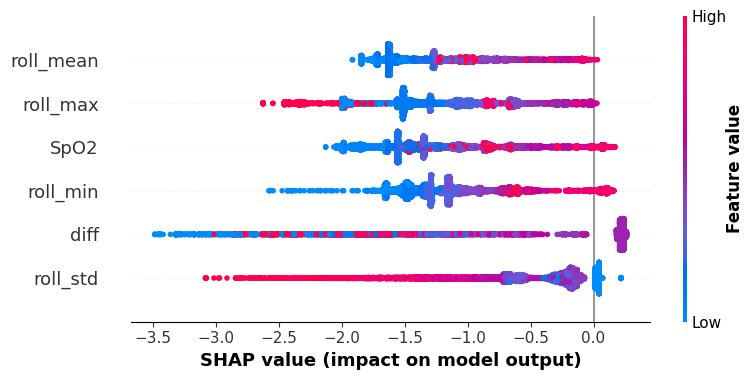

In [50]:
# 5.SHAP Explanability
import shap

plt.rcParams["figure.figsize"] = (10, 6)
# Prepare only the top 1% anomalies
X_anomalies = X_scaled[enriched_df['is_anomaly_5pct']]

# Create SHAP explainer using TreeExplainer (safe for Isolation Forest)
explainer = shap.TreeExplainer(iso, model_output='raw')

# Compute SHAP values
shap_values = explainer.shap_values(X_anomalies)

# Summary plot
features = ['SpO2', 'roll_mean', 'roll_std', 'roll_min', 'roll_max', 'diff']
shap.summary_plot(shap_values, X_anomalies, feature_names=features)


In [51]:
# Filter rows where the anomaly score is below 1% threshold (you may change to 3pct or 5pct)
anomalous_rows = enriched_df[enriched_df['is_anomaly_5pct']]

# Get unique Patient IDs who have at least one anomalous segment
anomalous_patient_ids = anomalous_rows['Patient_ID'].unique()

print(f"Number of patients with 1% anomalies: {len(anomalous_patient_ids)}")
print("Patient IDs:", anomalous_patient_ids)
anomaly_counts = anomalous_rows['Patient_ID'].value_counts()
print(anomaly_counts)

Number of patients with 1% anomalies: 35
Patient IDs: ['010217A' '010217B' '010217C' '010317A' '010317B' '051216A' '070217A'
 '080217A' '080217B' '081216A' '090217A' '090217B' '101216B' '101216C'
 '121216A' '121216B' '140317A' '150317A' '150317B' '160217A' '160217B'
 '160217C' '160217D' '160217E' '210217A' '210217B' '210217C' '230117A'
 '230117B' '250117A' '250117B' '250117C' '300117A' '301116A' '301116B']
Patient_ID
010317B    2137
010217C    1771
230117B     432
010317A     353
160217D     295
101216C     233
250117A     221
090217B     130
121216B     128
051216A     127
210217C      95
230117A      80
090217A      74
160217C      54
300117A      52
010217B      51
160217E      50
250117B      46
210217A      44
080217A      41
101216B      37
080217B      36
150317A      32
121216A      25
150317B      22
250117C      21
160217A      17
160217B      14
081216A      13
010217A      12
140317A      12
301116A      11
070217A       8
210217B       8
301116B       8
Name: count, dtype:

/tmp/ipython-input-3757965546.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomaly_counts.values, y=anomaly_counts.index, palette="coolwarm")


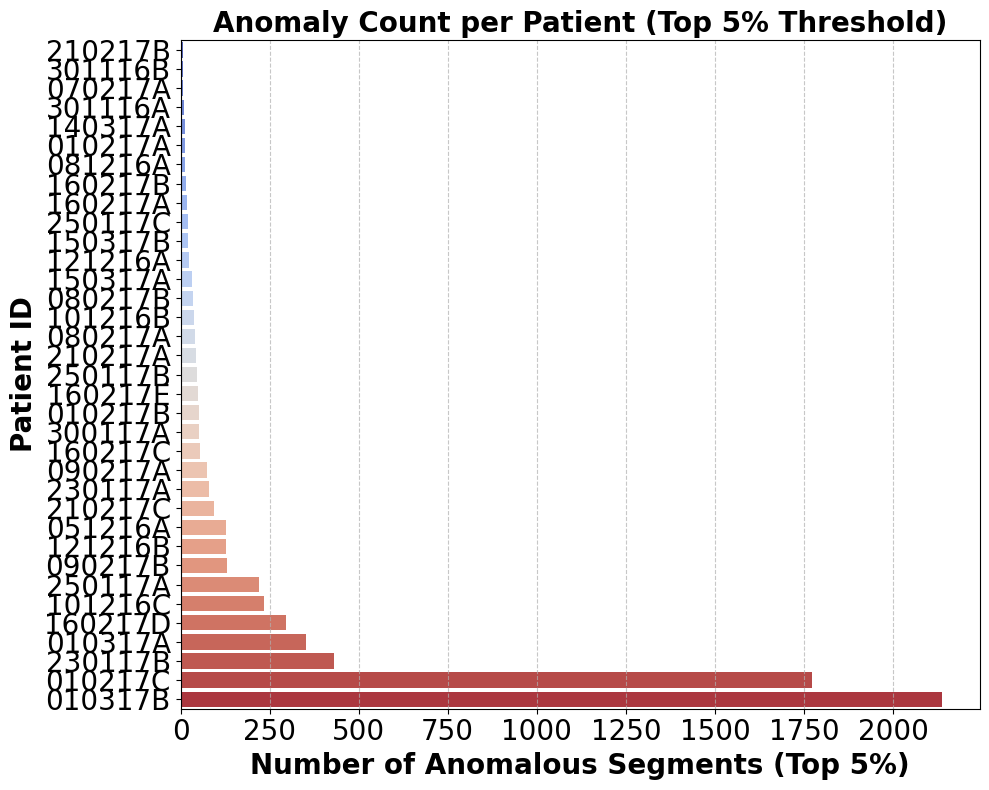

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only the 1% anomalies
anomalous_rows = enriched_df[enriched_df['is_anomaly_5pct']]

# Count how many anomalies per patient
anomaly_counts = anomalous_rows['Patient_ID'].value_counts().sort_values(ascending=True)

# Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x=anomaly_counts.values, y=anomaly_counts.index, palette="coolwarm")

plt.xlabel("Number of Anomalous Segments (Top 5%)")
plt.ylabel("Patient ID")
plt.title("Anomaly Count per Patient (Top 5% Threshold)")
plt.tight_layout()
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


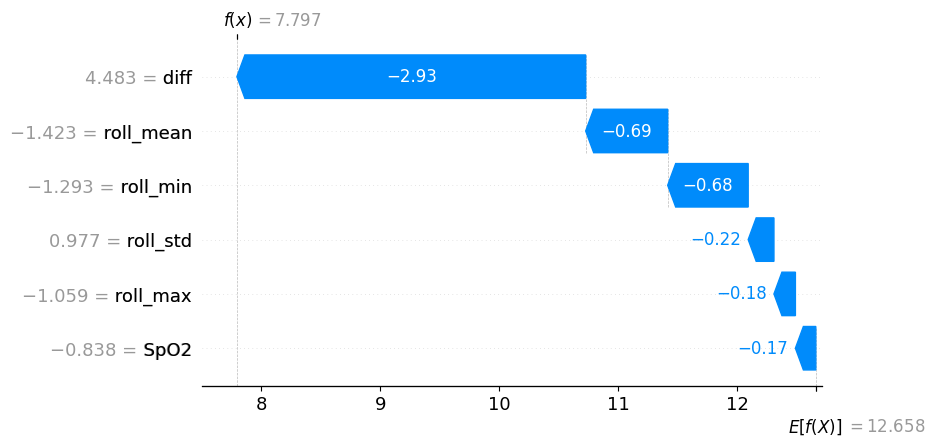

In [54]:
# SHAP watherfall: Step 1 for single parient : Filter anomalies for patient 010317B
##pid = "010217C"
#pid="101216C"
pid = "160217C" #second patient
anomalous_rows = enriched_df[(enriched_df['Patient_ID'] == pid) & (enriched_df['is_anomaly_5pct'])]

# SHAP watherfall Step 2: Get the index of the most anomalous sample (lowest score)
if anomalous_rows.empty:
    print(f"No 1% anomalies found for patient {pid}")
else:
    most_anomalous_idx = anomalous_rows['anomaly_score'].idxmin()

    # SHAP watherfall Step 3: Get feature values
    feature_names = ['SpO2', 'roll_mean', 'roll_std', 'roll_min', 'roll_max', 'diff']
    X_raw_row = enriched_df.loc[most_anomalous_idx, feature_names].values.reshape(1, -1)
    X_scaled_row = scaler.transform(X_raw_row)

    # SHAP watherfall Step 4: Compute SHAP values
    shap_vals = explainer.shap_values(X_scaled_row)[0]  # single row

    # SHAP watherfall Step 5: Build SHAP Explanation object
    expl = shap.Explanation(
        values=shap_vals,
        base_values=explainer.expected_value,
        data=X_scaled_row[0],
        feature_names=feature_names
    )
    plt.rcParams["figure.figsize"] = (10, 6)
    # SHAP watherfall Step 6: Plot
    shap.plots.waterfall(expl)


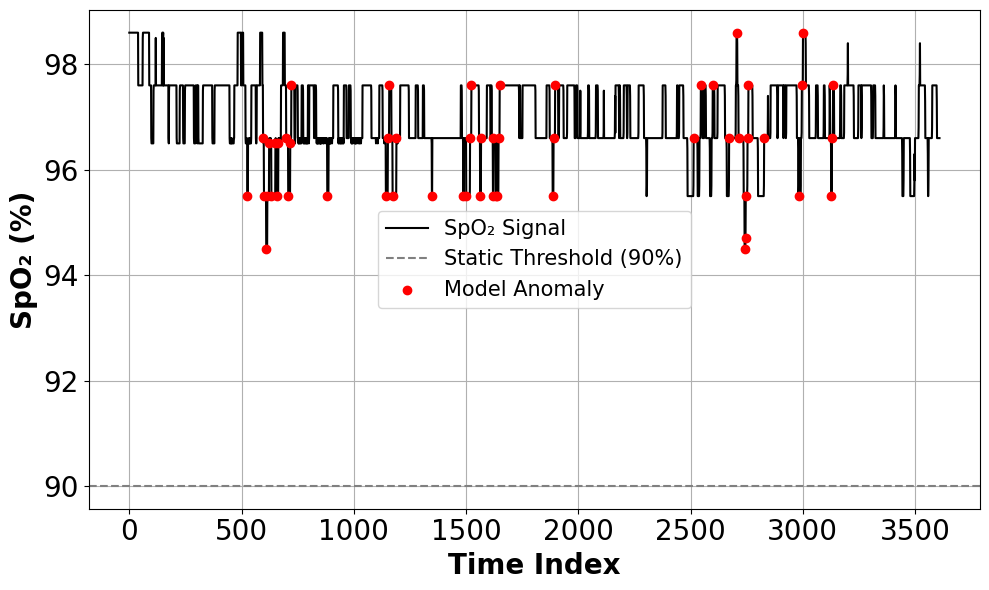

In [55]:
# 6. Validation of Threshold Vs Isolation Forest
#pid = "010217C"
pid="160217C"
window = enriched_df[enriched_df['Patient_ID'] == pid].reset_index()

plt.figure(figsize=(10, 6))
plt.plot(window['Time_Index'], window['SpO2'], label='SpO₂ Signal', color='black')
plt.legend(loc="lower left", bbox_to_anchor=(1.0, 0.5))
plt.axhline(y=90, color='gray', linestyle='--', label='Static Threshold (90%)')

# Model-based anomalies
model_anomalies = window[window['is_anomaly_5pct']]
plt.scatter(model_anomalies['Time_Index'], model_anomalies['SpO2'],
            color='red', label='Model Anomaly', zorder=5)

# Threshold-based anomalies
threshold_anomalies = window[window['SpO2'] < 90]
plt.scatter(threshold_anomalies['Time_Index'], threshold_anomalies['SpO2'],
            color='orange', zorder=5)

plt.rcParams.update({
    'axes.labelsize': 20,         # x and y label size
    'axes.labelweight': 'bold',   # make labels bold
    'xtick.labelsize': 20,        # x tick size
    'ytick.labelsize': 20,        # y tick size
    'axes.titlesize': 20,         # subplot/figure title size
    'axes.titleweight': 'bold',   # subplot/figure title bold
    'legend.fontsize': 15         # legend text size
})
plt.xlabel("Time Index",fontsize=20)
plt.ylabel("SpO₂ (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()
